In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB, CategoricalNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, classification_report,
    mean_squared_error
)
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
import warnings

In [ ]:
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [ ]:
from google.colab import drive

TRAIN_FILE ='/content/drive/MyDrive/Colab Notebooks/Train.csv'
TEST_FILE = '/content/drive/MyDrive/Colab Notebooks/Test.csv'

In [ ]:
TARGET_COLUMN = 'Segmentation'
ID_COLUMN = 'ID'
Var_1 = 'Var_1'

In [ ]:
NUMERICAL_FEATURES = ['Age', 'Work_Experience', 'Family_Size']
CATEGORICAL_FEATURES = ['Gender', 'Ever_Married', 'Graduated', 'Profession','Spending_Score']

In [ ]:
df_train = pd.read_csv(TRAIN_FILE)
print(df_train)

          ID  Gender Ever_Married  Age Graduated     Profession  \
0     462809    Male           No   22        No     Healthcare   
1     462643  Female          Yes   38       Yes       Engineer   
2     466315  Female          Yes   67       Yes       Engineer   
3     461735    Male          Yes   67       Yes         Lawyer   
4     462669  Female          Yes   40       Yes  Entertainment   
...      ...     ...          ...  ...       ...            ...   
8063  464018    Male           No   22        No            NaN   
8064  464685    Male           No   35        No      Executive   
8065  465406  Female           No   33       Yes     Healthcare   
8066  467299  Female           No   27       Yes     Healthcare   
8067  461879    Male          Yes   37       Yes      Executive   

      Work_Experience Spending_Score  Family_Size  Var_1 Segmentation  
0                 1.0            Low          4.0  Cat_4            D  
1                 NaN        Average          3.0  

In [ ]:
df_test_for_prediction = pd.read_csv(TEST_FILE)

In [ ]:
#Описательная статистика для тренировочных данных
print(df_train[NUMERICAL_FEATURES].describe())

               Age  Work_Experience  Family_Size
count  8068.000000      7239.000000  7733.000000
mean     43.466906         2.641663     2.850123
std      16.711696         3.406763     1.531413
min      18.000000         0.000000     1.000000
25%      30.000000         0.000000     2.000000
50%      40.000000         1.000000     3.000000
75%      53.000000         4.000000     4.000000
max      89.000000        14.000000     9.000000


In [ ]:
print(df_train[CATEGORICAL_FEATURES].describe())

       Gender Ever_Married Graduated Profession Spending_Score
count    8068         7928      7990       7944           8068
unique      2            2         2          9              3
top      Male          Yes       Yes     Artist            Low
freq     4417         4643      4968       2516           4878


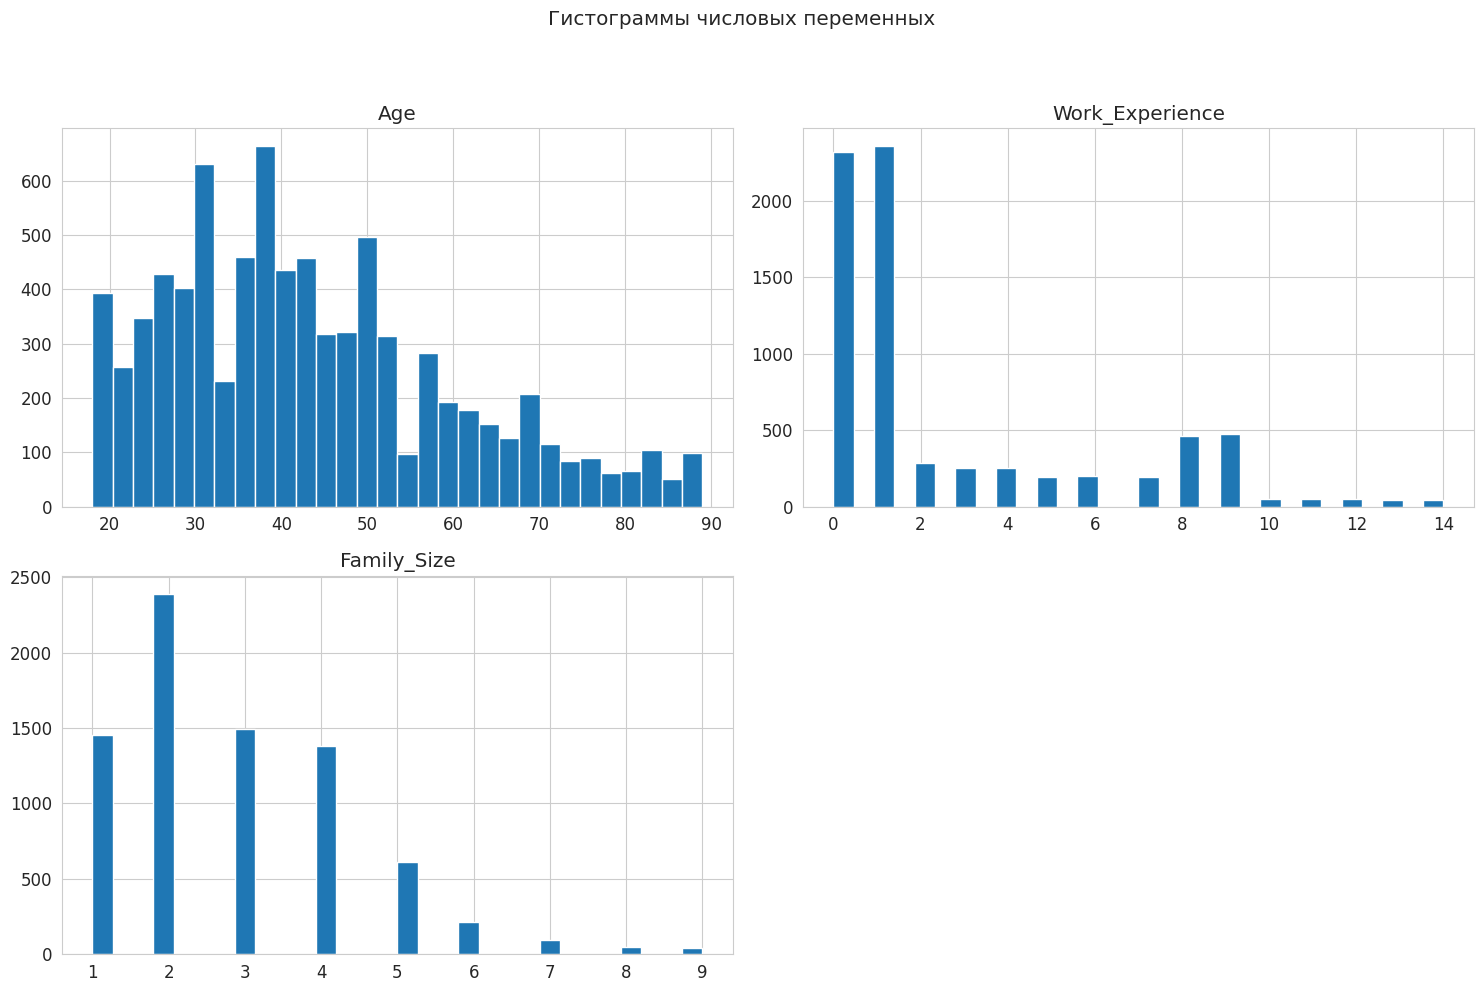

In [ ]:
# Визуализация для тренировочных данных
df_train[NUMERICAL_FEATURES].hist(bins=30, figsize=(15, 10))
plt.suptitle("Гистограммы числовых переменных", y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

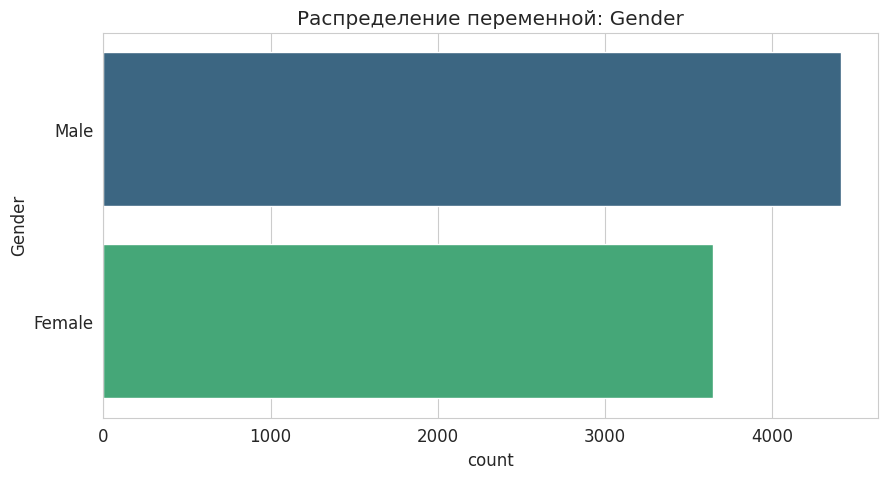

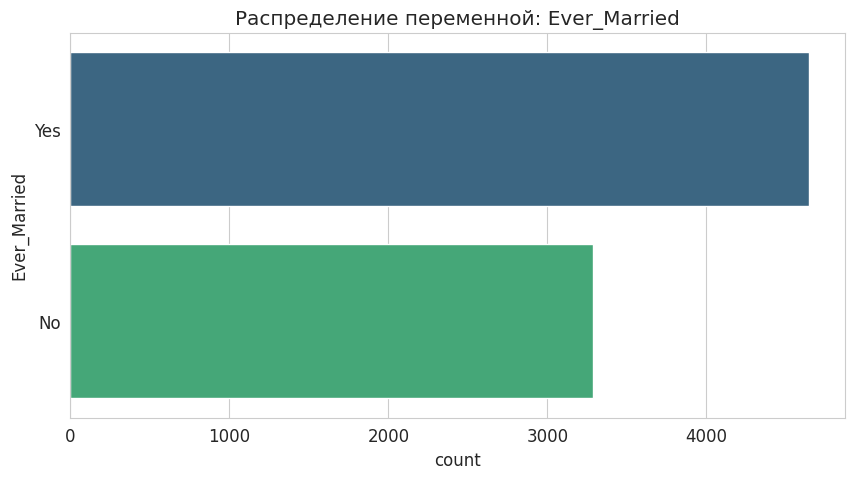

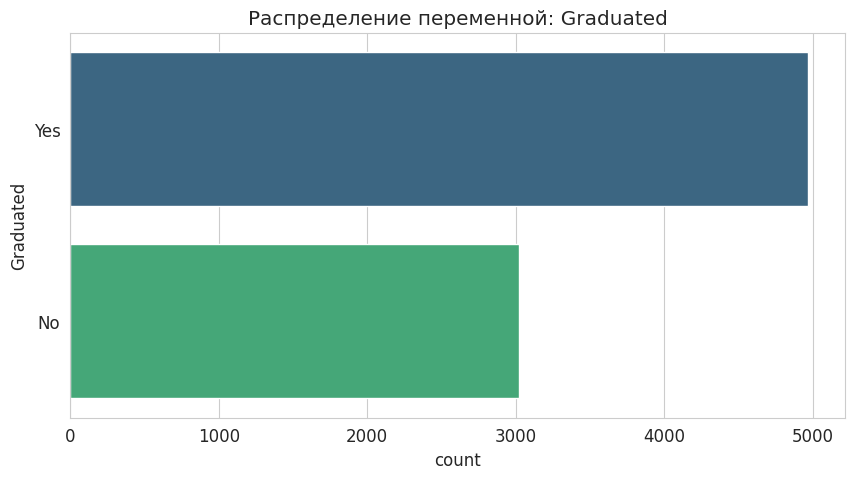

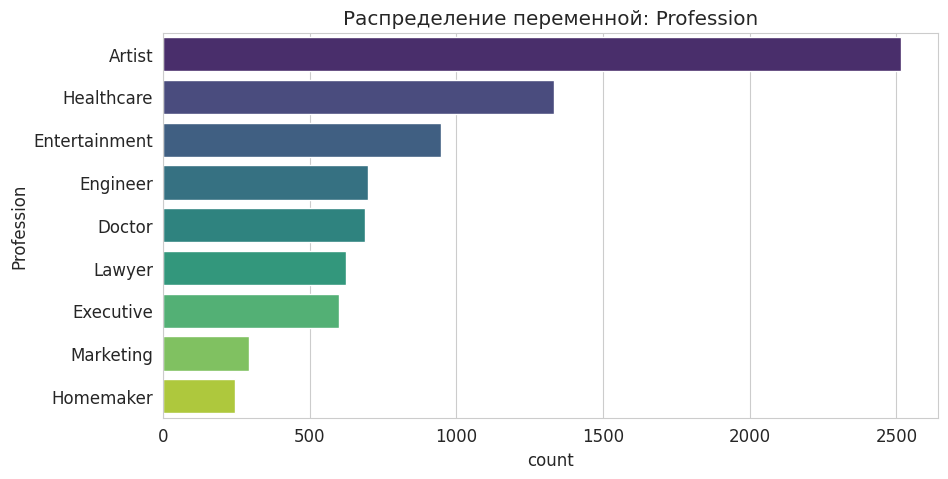

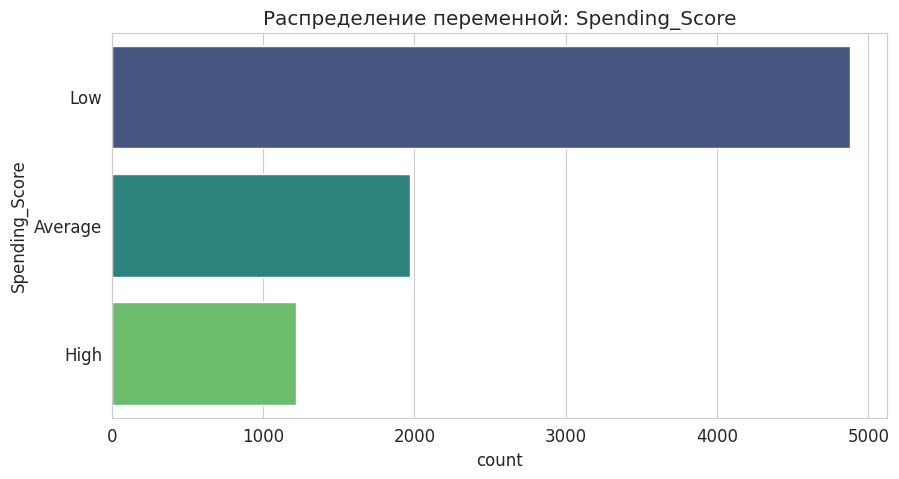

In [ ]:
for col in CATEGORICAL_FEATURES:
    plt.figure(figsize=(10, 5))
    sns.countplot(y=col, data=df_train, order=df_train[col].value_counts().index, palette='viridis')
    plt.title(f'Распределение переменной: {col}')
    plt.show()

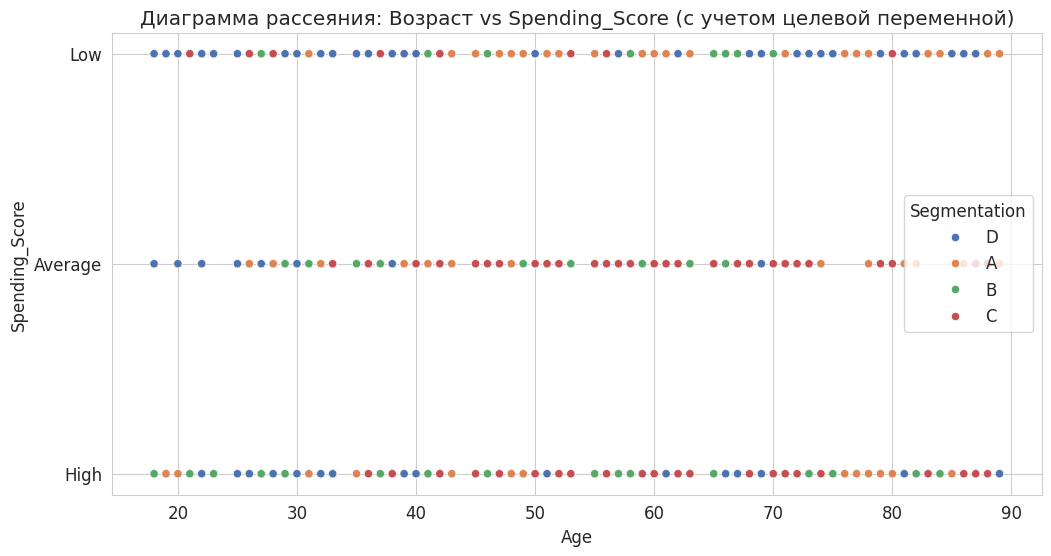

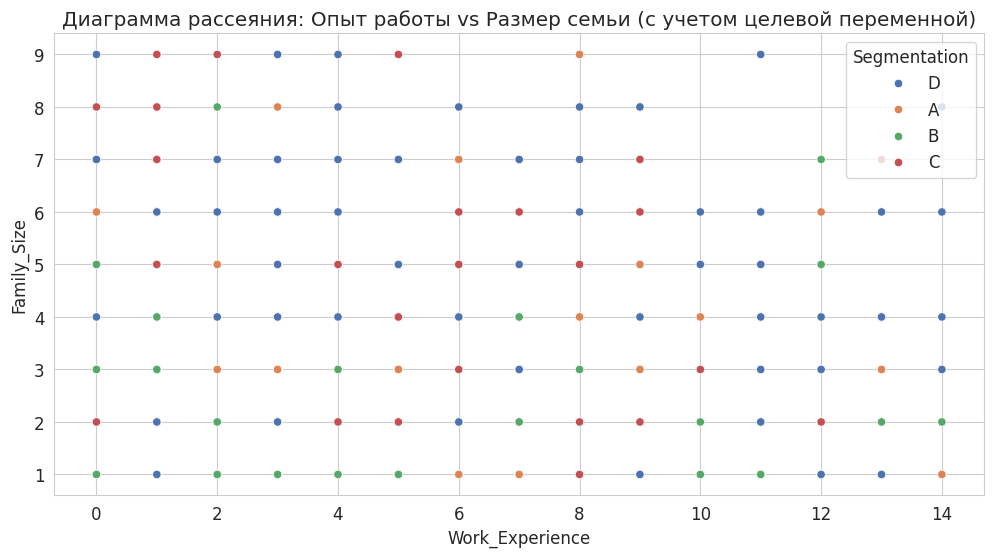

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Age', y='Spending_Score', hue=TARGET_COLUMN, data=df_train, palette='deep')
plt.title('Диаграмма рассеяния: Возраст vs Spending_Score (с учетом целевой переменной)')
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Work_Experience', y='Family_Size', hue=TARGET_COLUMN, data=df_train, palette='deep')
plt.title('Диаграмма рассеяния: Опыт работы vs Размер семьи (с учетом целевой переменной)')
plt.show()


4. Тепловая карта корреляции:


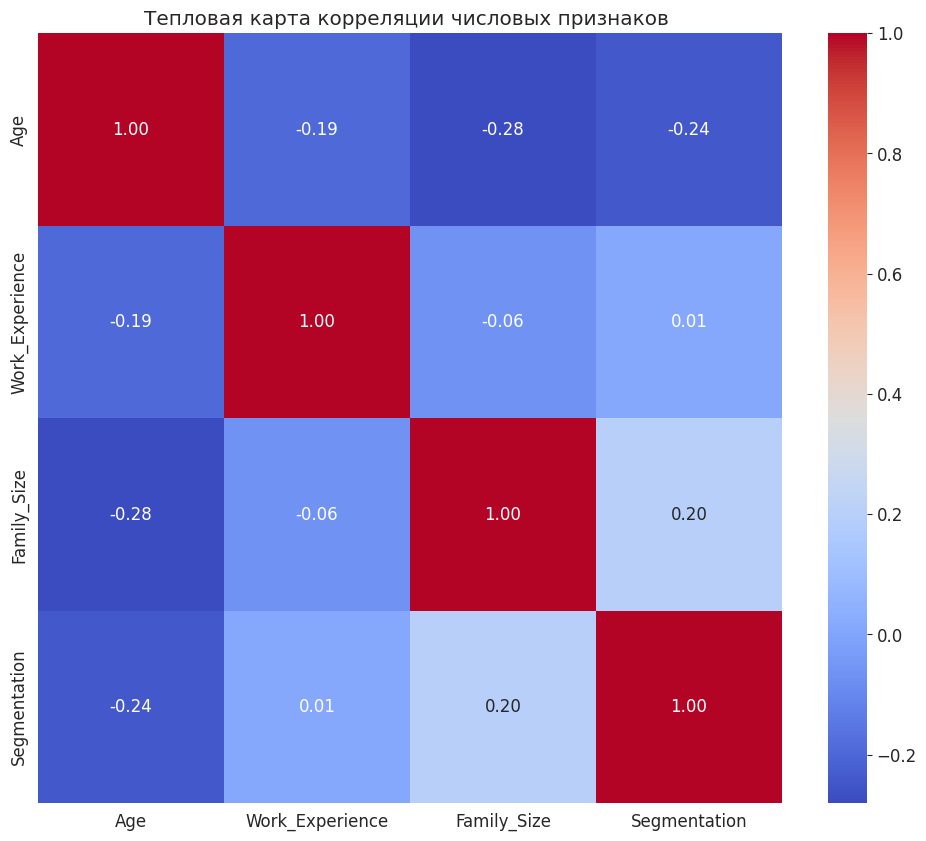

In [ ]:
print("\n4. Тепловая карта корреляции:")
temp_df_corr = df_train[NUMERICAL_FEATURES].copy()
temp_df_corr[TARGET_COLUMN] = LabelEncoder().fit_transform(df_train[TARGET_COLUMN])

plt.figure(figsize=(12, 10))
sns.heatmap(temp_df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Тепловая карта корреляции числовых признаков ')
plt.show()

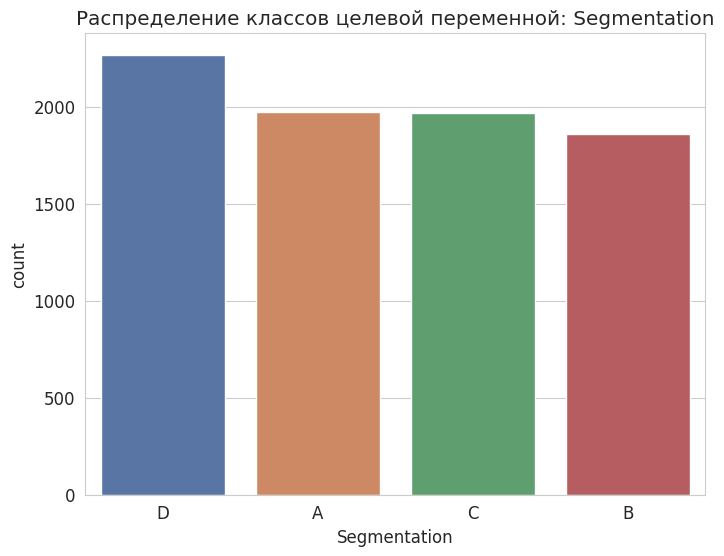

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x=TARGET_COLUMN, data=df_train, palette='deep', order=df_train[TARGET_COLUMN].value_counts().index)
plt.title(f'Распределение классов целевой переменной: {TARGET_COLUMN}')
plt.show()

In [ ]:
#Очистка данных
df_cleaned_train = df_train.copy()
df_cleaned_test_for_prediction = df_test_for_prediction.copy()

In [ ]:
#Обработка пропущенных значений
print("Пропущенные значения и их процент (для df_train):")
missing_pct_train = df_cleaned_train.isnull().mean() * 100
print(missing_pct_train[missing_pct_train > 0].sort_values(ascending=False))

print("\nПропущенные значения и их процент (для df_test_for_prediction):")
missing_pct_test = df_cleaned_test_for_prediction.isnull().mean() * 100
print(missing_pct_test[missing_pct_test > 0].sort_values(ascending=False))

Пропущенные значения и их процент (для df_train):
Work_Experience    10.275161
Family_Size         4.152206
Ever_Married        1.735250
Profession          1.536936
Graduated           0.966782
Var_1               0.941993
dtype: float64

Пропущенные значения и их процент (для df_test_for_prediction):
Work_Experience    10.239817
Family_Size         4.301485
Ever_Married        1.903312
Profession          1.446517
Var_1               1.218120
Graduated           0.913590
dtype: float64


In [ ]:
for col in NUMERICAL_FEATURES:
    if df_cleaned_train[col].isnull().any() or df_cleaned_test_for_prediction[col].isnull().any():
        median_val = df_cleaned_train[col].median() # Медиана берется только из df_train
        df_cleaned_train[col].fillna(median_val, inplace=True)
        df_cleaned_test_for_prediction[col].fillna(median_val, inplace=True)
        print(f"  Пропущенные значения в '{col}' заполнены медианой ({median_val:.2f}) из тренировочных данных.")

  Пропущенные значения в 'Work_Experience' заполнены медианой (1.00) из тренировочных данных.
  Пропущенные значения в 'Family_Size' заполнены медианой (3.00) из тренировочных данных.


In [ ]:
for col in CATEGORICAL_FEATURES:
    if df_cleaned_train[col].isnull().any() or df_cleaned_test_for_prediction[col].isnull().any():
        mode_val = df_cleaned_train[col].mode()[0] # Мода берется только из df_train
        df_cleaned_train[col].fillna(mode_val, inplace=True)
        df_cleaned_test_for_prediction[col].fillna(mode_val, inplace=True)
        print(f"  Пропущенные значения в '{col}' заполнены модой ('{mode_val}') из тренировочных данных.")

  Пропущенные значения в 'Ever_Married' заполнены модой ('Yes') из тренировочных данных.
  Пропущенные значения в 'Graduated' заполнены модой ('Yes') из тренировочных данных.
  Пропущенные значения в 'Profession' заполнены модой ('Artist') из тренировочных данных.


In [ ]:
print(df_cleaned_train.isnull().sum()[df_cleaned_train.isnull().sum() > 0])
print("Пропущенные значения после обработки (для df_test_for_prediction):")
print(df_cleaned_test_for_prediction.isnull().sum()[df_cleaned_test_for_prediction.isnull().sum() > 0])
if df_cleaned_train.isnull().sum().sum() == 0 and df_cleaned_test_for_prediction.isnull().sum().sum() == 0:
    print("Все пропущенные значения обработаны.")

Var_1    76
dtype: int64
Пропущенные значения после обработки (для df_test_for_prediction):
Var_1    32
dtype: int64


In [ ]:
for col in NUMERICAL_FEATURES:
    Q1 = df_cleaned_train[col].quantile(0.25)
    Q3 = df_cleaned_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_train_count = df_cleaned_train[(df_cleaned_train[col] < lower_bound) | (df_cleaned_train[col] > upper_bound)].shape[0]
    if outliers_train_count > 0:
        print(f"  В '{col}' (df_train) обнаружено {outliers_train_count} выбросов.")
        df_cleaned_train[col] = np.where(df_cleaned_train[col] < lower_bound, lower_bound, df_cleaned_train[col])
        df_cleaned_train[col] = np.where(df_cleaned_train[col] > upper_bound, upper_bound, df_cleaned_train[col])
        print(f"  Выбросы в '{col}' (df_train) заменены на пороговые значения (capping: [{lower_bound:.2f}, {upper_bound:.2f}]).")
    else:
        print(f"  В '{col}' (df_train) выбросов не обнаружено (по методу IQR).")

    outliers_test_pred_count = df_cleaned_test_for_prediction[(df_cleaned_test_for_prediction[col] < lower_bound) | (df_cleaned_test_for_prediction[col] > upper_bound)].shape[0]
    if outliers_test_pred_count > 0:
        print(f"  В '{col}' (df_test_for_prediction) обнаружено {outliers_test_pred_count} выбросов.")
        df_cleaned_test_for_prediction[col] = np.where(df_cleaned_test_for_prediction[col] < lower_bound, lower_bound, df_cleaned_test_for_prediction[col])
        df_cleaned_test_for_prediction[col] = np.where(df_cleaned_test_for_prediction[col] > upper_bound, upper_bound, df_cleaned_test_for_prediction[col])
        print(f"  Выбросы в '{col}' (df_test_for_prediction) заменены на пороговые значения (capping).")
    else:
        print(f"  В '{col}' (df_test_for_prediction) выбросов не обнаружено (по методу IQR).")

  В 'Age' (df_train) обнаружено 71 выбросов.
  Выбросы в 'Age' (df_train) заменены на пороговые значения (capping: [-4.50, 87.50]).
  В 'Age' (df_test_for_prediction) обнаружено 19 выбросов.
  Выбросы в 'Age' (df_test_for_prediction) заменены на пороговые значения (capping).
  В 'Work_Experience' (df_train) обнаружено 189 выбросов.
  Выбросы в 'Work_Experience' (df_train) заменены на пороговые значения (capping: [-6.00, 10.00]).
  В 'Work_Experience' (df_test_for_prediction) обнаружено 58 выбросов.
  Выбросы в 'Work_Experience' (df_test_for_prediction) заменены на пороговые значения (capping).
  В 'Family_Size' (df_train) обнаружено 94 выбросов.
  Выбросы в 'Family_Size' (df_train) заменены на пороговые значения (capping: [-1.00, 7.00]).
  В 'Family_Size' (df_test_for_prediction) обнаружено 31 выбросов.
  Выбросы в 'Family_Size' (df_test_for_prediction) заменены на пороговые значения (capping).


In [ ]:
initial_rows_train = df_cleaned_train.shape[0]
df_cleaned_train.drop_duplicates(inplace=True)
removed_rows_train = initial_rows_train - df_cleaned_train.shape[0]
print(f"Удалено {removed_rows_train} дубликатов из df_train. Новое количество строк: {df_cleaned_train.shape[0]}.")


Удалено 0 дубликатов из df_train. Новое количество строк: 8068.


In [ ]:
low_information_cols = []
num_rows_train = len(df_cleaned_train)
for col in df_cleaned_train.columns:
    if col not in [ID_COLUMN, TARGET_COLUMN]:
        cnts = df_cleaned_train[col].value_counts(dropna=False)
        if not cnts.empty:
            top_pct = (cnts.iloc[0] / num_rows_train)
            if top_pct > 0.95:
                low_information_cols.append(col)
                print(f"  Признак '{col}': {top_pct:.2%} одинаковых значений. Рекомендуется рассмотреть удаление.")

if not low_information_cols:
    print("  Неинформативных признаков (с >95% одинаковых значений) не обнаружено.")

  Неинформативных признаков (с >95% одинаковых значений) не обнаружено.


In [ ]:
BINARY_CATEGORICAL_FEATURES_EXT = [col for col in ['Gender', 'Ever_Married', 'Graduated'] if col in CATEGORICAL_FEATURES]
ORDINAL_CATEGORICAL_FEATURES_EXT = [col for col in ['Spending_Score'] if col in CATEGORICAL_FEATURES]
NOMINAL_CATEGORICAL_FEATURES_EXT = [col for col in ['Profession'] if col in CATEGORICAL_FEATURES]

# Задаем порядок для OrdinalEncoder
SPENDING_SCORE_ORDER = ['Low', 'Average', 'High']

In [ ]:
label_encoders = {}
ordinal_encoders = {}
onehot_encoders = {}

In [ ]:
#Преобразование категориальных признаков
for col in BINARY_CATEGORICAL_FEATURES_EXT:
    le = LabelEncoder()
    df_cleaned_train[col] = le.fit_transform(df_cleaned_train[col])
    df_cleaned_test_for_prediction[col] = le.transform(df_cleaned_test_for_prediction[col])
    label_encoders[col] = le
    print(f"  '{col}' (бинарный) закодирован LabelEncoder'ом. Уникальные значения в train: {np.unique(df_cleaned_train[col])}")


  'Gender' (бинарный) закодирован LabelEncoder'ом. Уникальные значения в train: [0 1]
  'Ever_Married' (бинарный) закодирован LabelEncoder'ом. Уникальные значения в train: [0 1]
  'Graduated' (бинарный) закодирован LabelEncoder'ом. Уникальные значения в train: [0 1]


In [ ]:
for col in ORDINAL_CATEGORICAL_FEATURES_EXT:
    df_cleaned_train[col] = df_cleaned_train[col].astype(str)
    df_cleaned_test_for_prediction[col] = df_cleaned_test_for_prediction[col].astype(str)
    df_cleaned_train[col] = df_cleaned_train[col].str.strip().str.capitalize()
    df_cleaned_test_for_prediction[col] = df_cleaned_test_for_prediction[col].str.strip().str.capitalize()
    print(f"  (DEBUG) Уникальные значения в '{col}' после очистки: {df_cleaned_train[col].unique()}")

    oe = OrdinalEncoder(categories=[SPENDING_SCORE_ORDER], handle_unknown='use_encoded_value', unknown_value=-1)
    df_cleaned_train[col] = oe.fit_transform(df_cleaned_train[[col]])
    df_cleaned_test_for_prediction[col] = oe.transform(df_cleaned_test_for_prediction[[col]])
    ordinal_encoders[col] = oe
    print(f" '{col}' (порядковый) закодирован OrdinalEncoder'ом. Порядок: {SPENDING_SCORE_ORDER} -> {np.unique(df_cleaned_train[col])}")

  (DEBUG) Уникальные значения в 'Spending_Score' после очистки: ['Low' 'Average' 'High']
 'Spending_Score' (порядковый) закодирован OrdinalEncoder'ом. Порядок: ['Low', 'Average', 'High'] -> [0. 1. 2.]


In [ ]:
for col in NOMINAL_CATEGORICAL_FEATURES_EXT:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    ohe.fit(df_cleaned_train[[col]])
    onehot_encoders[col] = ohe

    # Создаем dummy-переменные для тренировочного набора
    new_cols_train = ohe.transform(df_cleaned_train[[col]])
    new_df_train = pd.DataFrame(new_cols_train, columns=ohe.get_feature_names_out([col]), index=df_cleaned_train.index)
    df_cleaned_train = pd.concat([df_cleaned_train.drop(columns=[col]), new_df_train], axis=1)

    # Создаем dummy-переменные для тестового набора
    new_cols_test = ohe.transform(df_cleaned_test_for_prediction[[col]])
    new_df_test = pd.DataFrame(new_cols_test, columns=ohe.get_feature_names_out([col]), index=df_cleaned_test_for_prediction.index)
    df_cleaned_test_for_prediction = pd.concat([df_cleaned_test_for_prediction.drop(columns=[col]), new_df_test], axis=1)

    print(f"{col} закодирован OneHotEncoder. Добавлены колонки: {ohe.get_feature_names_out([col]).tolist()}")


Profession закодирован OneHotEncoder. Добавлены колонки: ['Profession_Artist', 'Profession_Doctor', 'Profession_Engineer', 'Profession_Entertainment', 'Profession_Executive', 'Profession_Healthcare', 'Profession_Homemaker', 'Profession_Lawyer', 'Profession_Marketing']


In [ ]:
FINAL_NUMERICAL_FEATURES = list(NUMERICAL_FEATURES) # Колонки, которые были числовыми изначально
FINAL_NUMERICAL_FEATURES.extend(BINARY_CATEGORICAL_FEATURES_EXT) # Закодированные бинарные
FINAL_NUMERICAL_FEATURES.extend(ORDINAL_CATEGORICAL_FEATURES_EXT) # Закодированные порядковые
FINAL_NUMERICAL_FEATURES.extend(NOMINAL_CATEGORICAL_FEATURES_EXT)

# Обновим список всех признаков после OHE
all_features_for_X_train = [col for col in df_cleaned_train.columns if col not in [TARGET_COLUMN, ID_COLUMN, Var_1]]
all_features_for_X_test = [col for col in df_cleaned_test_for_prediction.columns if col not in [ID_COLUMN]]


In [ ]:
X = df_cleaned_train.drop(columns=[TARGET_COLUMN, ID_COLUMN, Var_1])
y = df_cleaned_train[TARGET_COLUMN]

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
target_class_names = label_encoder.classes_
print(f"Целевая переменная '{TARGET_COLUMN}' преобразована из {target_class_names} в {np.unique(y_encoded)}")

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Размер обучающей выборки (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Размер валидационной выборки (X_test, y_test): {X_test.shape}, {y_test.shape}")
print(f"Пропорции классов в y_train:\n{pd.Series(y_train).value_counts(normalize=True)}")
print(f"Пропорции классов в y_test:\n{pd.Series(y_test).value_counts(normalize=True)}")

Целевая переменная 'Segmentation' преобразована из ['A' 'B' 'C' 'D'] в [0 1 2 3]
Размер обучающей выборки (X_train, y_train): (6454, 16), (6454,)
Размер валидационной выборки (X_test, y_test): (1614, 16), (1614,)
Пропорции классов в y_train:
3    0.281066
0    0.244500
2    0.244190
1    0.230245
Name: proportion, dtype: float64
Пропорции классов в y_test:
3    0.281289
0    0.244114
2    0.244114
1    0.230483
Name: proportion, dtype: float64


In [ ]:
preprocessor = ColumnTransformer(
     transformers=[
         ('passthrough_features', 'passthrough', X.columns.tolist())
     ],
     remainder='drop'
 )
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CategoricalNB())
])

In [ ]:
# Обучение модели
model_pipeline.fit(X_train, y_train)

# Оценка качества модели
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test) # Для ROC-кривой

sse = mean_squared_error(y_test, y_pred) * len(y_test)
print(f"\n2. Сумма квадратов остатков (SSE): {sse:.4f}")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"  Точность (Accuracy): {accuracy:.4f}")
print(f"  Полнота (Precision) (weighted): {precision:.4f}")
print(f"  Чувствительность/Отзыв (Recall) (weighted): {recall:.4f}")
print(f"  F1-мера (F1-score) (weighted): {f1:.4f}")


2. Сумма квадратов остатков (SSE): 2523.0000
  Точность (Accuracy): 0.5173
  Полнота (Precision) (weighted): 0.5041
  Чувствительность/Отзыв (Recall) (weighted): 0.5173
  F1-мера (F1-score) (weighted): 0.5055



  Матрица ошибок (Confusion Matrix):
[[180  72  75  67]
 [105  86 147  34]
 [ 46  49 247  52]
 [ 82  29  21 322]]


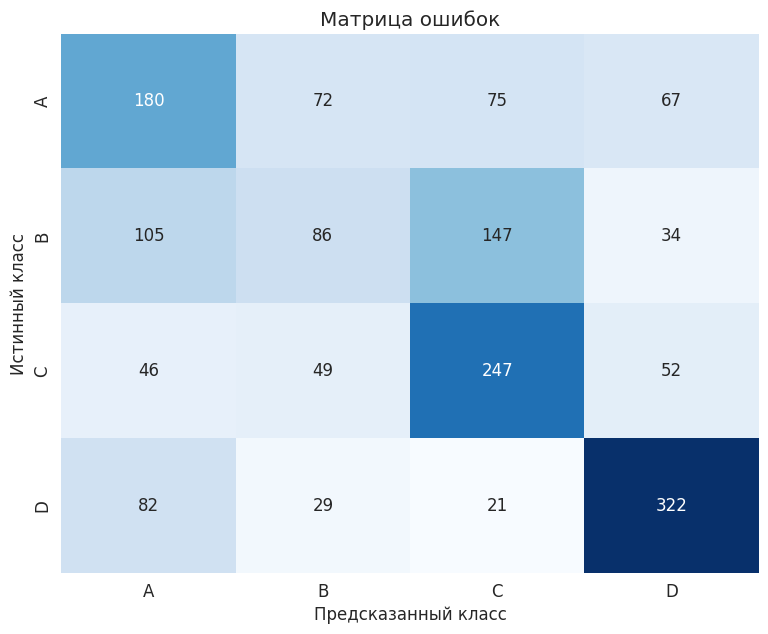

In [ ]:
print("\n  Матрица ошибок (Confusion Matrix):")
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_class_names, yticklabels=target_class_names)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()


  ROC-кривая и AUC (пример для одного класса 'one-vs-rest'):
  AUC для класса 'D' (one-vs-rest): 0.8812


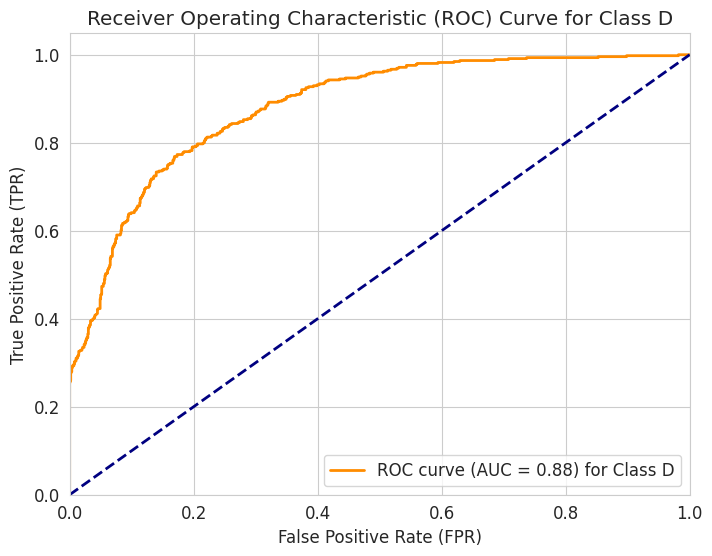

In [ ]:
# ROC-кривая и AUC (для мультиклассовой классификации, one-vs-rest подход)
print("\n  ROC-кривая и AUC (пример для одного класса 'one-vs-rest'):")
try:
    # Пример для класса 'A' (если 'A' соответствует 0 после LabelEncoding)
    target_class_to_plot = 'D'
    if target_class_to_plot in target_class_names:
        target_class_index = np.where(target_class_names == target_class_to_plot)[0][0]
        y_test_binary = (y_test == target_class_index).astype(int)
        y_pred_proba_class = y_pred_proba[:, target_class_index]

        fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_proba_class)
        roc_auc = auc(fpr, tpr)

        print(f"  AUC для класса '{target_class_names[target_class_index]}' (one-vs-rest): {roc_auc:.4f}")

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f}) for Class {target_class_names[target_class_index]}')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate (FPR)')
        plt.ylabel('True Positive Rate (TPR)')
        plt.title(f'Receiver Operating Characteristic (ROC) Curve for Class {target_class_names[target_class_index]}')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print(f"  Класс '{target_class_to_plot}' не найден среди целевых классов.")
except Exception as e:
    print(f"  Не удалось построить ROC-кривую для мультиклассовой классификации: {e}")
    print("  Для полноценной ROC-кривой в мультиклассе требуется более сложная реализация (например, усреднение по всем классам).")


In [ ]:
#Интерпретация результатов классификации (Профили клиентов по сегментам)
X_test_with_predictions = X_test.copy()
X_test_with_predictions['actual_target_encoded'] = y_test
X_test_with_predictions['predicted_target_encoded'] = y_pred

X_test_with_predictions['actual_target'] = label_encoder.inverse_transform(y_test)
X_test_with_predictions['predicted_target'] = label_encoder.inverse_transform(y_pred)

In [ ]:
print("\nАнализ характеристик каждого сегмента, предсказанного моделью (на валидационной выборке):")

for segment_encoded, segment_name in enumerate(target_class_names):
    print(f"\n--- Профиль клиентов, предсказанных как сегмент {segment_name} (класс {segment_encoded}) ---")
    segment_data = X_test_with_predictions[X_test_with_predictions['predicted_target_encoded'] == segment_encoded]

    if not segment_data.empty:
        # Анализ числовых признаков (оригинальные числовые)
        print("\nСредние значения числовых признаков для этого сегмента:")
        print(segment_data[NUMERICAL_FEATURES].mean().round(2))

        # Анализ бинарных и порядковых признаков (Label/Ordinal Encoded)
        print("\nНаиболее частые значения бинарных и порядковых признаков (раскодировано):")
        for col in BINARY_CATEGORICAL_FEATURES_EXT + ORDINAL_CATEGORICAL_FEATURES_EXT:
            if col in segment_data.columns and not segment_data[col].empty and not segment_data[col].isnull().all():
                mode_encoded = segment_data[col].mode()
                if not mode_encoded.empty:
                    mode_value = mode_encoded[0]
                    original_category = None
                    if col in label_encoders:
                        original_category = label_encoders[col].inverse_transform([int(mode_value)])[0]
                    elif col in ordinal_encoders:
                        original_category = ordinal_encoders[col].inverse_transform([[mode_value]])[0][0]
                    else:
                        original_category = f"Неизвестно (энкодер для '{col}' не найден)"

                    frequency = segment_data[col].value_counts(normalize=True).max()
                    print(f"- {col}: {original_category} (частота: {frequency:.2f})")
                else:
                    print(f"- {col}: Нет доминирующей моды.")
            else:
                print(f"- {col}: Нет данных для анализа или все значения NaN (после кодирования).")

        # Анализ номинальных признаков (One-Hot Encoded)
        print("\nНаиболее частые значения номинальных признаков (раскодировано):")
        for original_col in NOMINAL_CATEGORICAL_FEATURES_EXT:
            if original_col in onehot_encoders:
                ohe_columns = onehot_encoders[original_col].get_feature_names_out([original_col])
                existing_ohe_columns = [c for c in ohe_columns if c in segment_data.columns]

                if existing_ohe_columns:
                    ohe_means = segment_data[existing_ohe_columns].mean()
                    if not ohe_means.empty and ohe_means.max() > 0:
                        most_frequent_ohe_col = ohe_means.idxmax()
                        frequency = ohe_means.max()
                        original_category_name = most_frequent_ohe_col.replace(f"{original_col}_", "")
                        print(f"- {original_col}: {original_category_name} (частота: {frequency:.2f})")
                    else:
                        print(f"- {original_col}: Нет доминирующей категории (все нули или пустые).")
                else:
                    print(f"- {original_col}: Соответствующие OHE колонки не найдены в данных сегмента.")
            else:
                print(f"- {original_col}: Кодировщик OneHotEncoder не найден для обратного преобразования.")
    else:
        print(f"В валидационной выборке нет клиентов, предсказанных как сегмент {segment_name}.")



Анализ характеристик каждого сегмента, предсказанного моделью (на валидационной выборке):

--- Профиль клиентов, предсказанных как сегмент A (класс 0) ---

Средние значения числовых признаков для этого сегмента:
Age                45.33
Work_Experience     3.00
Family_Size         1.97
dtype: float64

Наиболее частые значения бинарных и порядковых признаков (раскодировано):
- Gender: Female (частота: 0.51)
- Ever_Married: No (частота: 0.51)
- Graduated: Yes (частота: 0.69)
- Spending_Score: Low (частота: 0.87)

Наиболее частые значения номинальных признаков (раскодировано):
- Profession: Artist (частота: 0.35)

--- Профиль клиентов, предсказанных как сегмент B (класс 1) ---

Средние значения числовых признаков для этого сегмента:
Age                54.35
Work_Experience     1.61
Family_Size         2.72
dtype: float64

Наиболее частые значения бинарных и порядковых признаков (раскодировано):
- Gender: Male (частота: 0.59)
- Ever_Married: Yes (частота: 0.94)
- Graduated: Yes (частота: 

In [ ]:
print("ФИНАЛЬНОЕ ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ ('test.csv')")

df_ids_for_prediction = df_cleaned_test_for_prediction[ID_COLUMN]
X_for_final_prediction = df_cleaned_test_for_prediction.drop(columns=[ID_COLUMN])

print(f"\nРазмерность данных для финальных предсказаний: {X_for_final_prediction.shape}")
print("Применяем обученный пайплайн (препроцессор + классификатор) к тестовым данным")

final_predictions_encoded = model_pipeline.predict(X_for_final_prediction)

final_predictions_segment_names = label_encoder.inverse_transform(final_predictions_encoded)

print("Предсказания успешно получены.")

predictions_df = pd.DataFrame({
    ID_COLUMN: df_ids_for_prediction,
    TARGET_COLUMN: final_predictions_segment_names
})

print("\nПервые 10 предсказаний для тестового файла:")
print(predictions_df.head(10))

OUTPUT_PREDICTIONS_FILE = 'submission_predictions.csv'
predictions_df.to_csv(OUTPUT_PREDICTIONS_FILE, index=False)
print(f"\nПредсказания сохранены в файл: '{OUTPUT_PREDICTIONS_FILE}'")

ФИНАЛЬНОЕ ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ ('test.csv')

Размерность данных для финальных предсказаний: (2627, 18)
Применяем обученный пайплайн (препроцессор + классификатор) к тестовым данным
Предсказания успешно получены.

Первые 10 предсказаний для тестового файла:
       ID Segmentation
0  458989            A
1  458994            C
2  458996            A
3  459000            B
4  459001            D
5  459003            C
6  459005            C
7  459008            C
8  459013            C
9  459014            D

Предсказания сохранены в файл: 'submission_predictions.csv'
